# LLM usage Analysis

In [17]:
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('../datasets/projects_parameter_assignments.csv')
df

,project_name,path,lineno,parameter,value
0,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,232,temperature,0.9
1,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,233,top_p,1.0
2,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,239,max_tokens,4096
3,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,248,model,XT
4,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,256,model,dall-e-3
...,...,...,...,...,...
7389,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,148,frequency_penalty,1
7390,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,top_p,0.9
7391,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,max_tokens,500
7392,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,temperature,1


In [19]:
df_without_model = pd.read_csv('../datasets/projects_parameter_assignments.csv')
df_without_model = df_without_model.loc[df_without_model['parameter'] != 'model']
df_without_model

,project_name,path,lineno,parameter,value
0,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,232,temperature,0.9
1,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,233,top_p,1.0
2,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,239,max_tokens,4096
6,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,229,temperature,0.9
7,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,229,top_p,1.0
...,...,...,...,...,...
7389,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,148,frequency_penalty,1
7390,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,top_p,0.9
7391,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,max_tokens,500
7392,khoj,/home/aolmedo/Research/AI_config/projects/khoj...,43,temperature,1


In [20]:
df_only_model = pd.read_csv('../datasets/projects_parameter_assignments.csv')
df_only_model = df_only_model.loc[df_only_model['parameter'] == 'model']
df_only_model

,project_name,path,lineno,parameter,value
3,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,248,model,XT
4,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,256,model,dall-e-3
5,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,361,model,unsloth/mistral-7b-v0.2
9,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,246,model,XT
10,AGiXT,/home/aolmedo/Research/AI_config/projects/AGiX...,254,model,dall-e-3
...,...,...,...,...,...
7315,gpt-voice-conversation-chatbot,/home/aolmedo/Research/AI_config/projects/gpt-...,21,model,eleven_multilingual_v1
7328,gpt-voice-conversation-chatbot,/home/aolmedo/Research/AI_config/projects/gpt-...,1033,model,gpt-3.5-turbo
7330,safe-rlhf,/home/aolmedo/Research/AI_config/projects/safe...,115,model,gpt-4
7343,Groma,/home/aolmedo/Research/AI_config/projects/Grom...,14,model,gpt-4-0613


In [29]:
!pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip 

     \ 17.9 MB 6.0 MB/s 0:00:03m0m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 KB 3.6 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 5.4 MB/s eta 0:00:005.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 5.7 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 6.0 MB/s eta 0:00:00m eta 0:00:010:00:01
  Using cached multimethod-1.12-py3-none-any.whl (10 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached wordcloud-1.9.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (511 kB)
  Using cached visions-0.8.1-py3-none-any.whl (105 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 677.6/677.6 KB 5.4 MB/s eta 0:00:000:00:01m eta 0:00:01
  Using cached dacite-1.9.2-py3-none-any.whl (16 kB)
  Using cached matp

In [32]:
import ydata_profiling
df_2 = df_only_model.drop(columns=['path', 'lineno', 'parameter'])
profile = ydata_profiling.ProfileReport(df_2)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 73.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
import ydata_profiling
df_3 = df_without_model.drop(columns=['path', 'lineno'])
profile = ydata_profiling.ProfileReport(df_3)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 113.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## How many projects define the LLM parameters and how many do not?

In [21]:
selected_projects = 734
project_define_params = df['project_name'].value_counts().shape[0]
define_param_percentage = (project_define_params / selected_projects)
# print("El 55% de los proyectos no definen parámetros mientras: ", round((1 - percentage) * 100, 2))
define_param_percentage

0.5449591280653951

Total number of projects: 734
Number of projects that configure any parameter: 400
Percentage of projects that configure any parameter: 0.5449591280653951


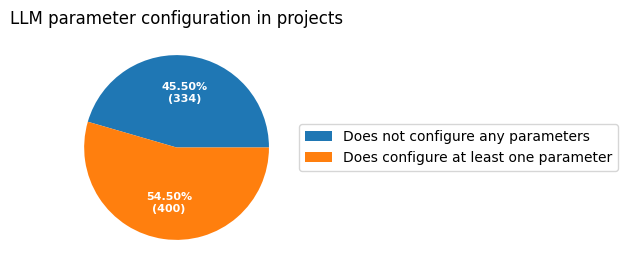

In [22]:
print('Total number of projects:', selected_projects)
print('Number of projects that configure any parameter:', project_define_params)
print('Percentage of projects that configure any parameter:', project_define_params/selected_projects)

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

data = [selected_projects - project_define_params, project_define_params]
labels = ['Does not configure any parameters', 'Does configure at least one parameter']


def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.2f}%\n({absolute:d})"


wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct, data),
                                  textprops=dict(color="w"))

ax.legend(wedges, labels,
          title="",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("LLM parameter configuration in projects")

plt.show()

## How many parameters does each project define?

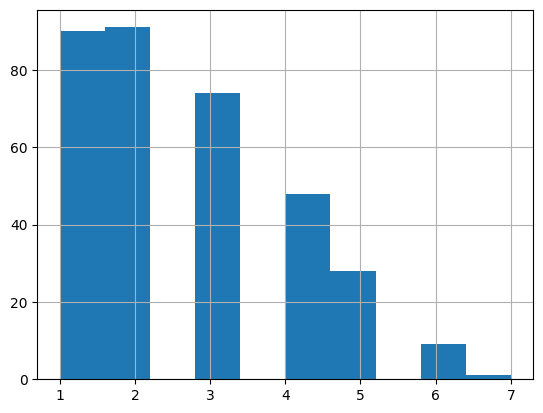

In [23]:
total_parameter = 8

# df.groupby(['project_name', 'parameter']).count()
df_4 = df_without_model.drop(columns=['path', 'lineno', 'value'])
#t = df_4.groupby(['project_name']).count()

t = df_4.value_counts().groupby(['project_name']).count()
t.hist()

d = df_4.value_counts().groupby(['project_name']).count().apply(lambda x: (x/total_parameter)*100)
#d.plot.hist()

## How many parameters are defined in a project on average?

In [24]:
df_4 = df_without_model.drop(columns=['path', 'lineno', 'value'])
df_4.value_counts().groupby(['project_name']).count().mean()
sorted(list(df_4.value_counts().groupby(['project_name']).count()))[131]

2

## What is the most configured parameter in all projects?

In [25]:
df_4 = df_without_model.drop(columns=['path', 'lineno'])
df_4.groupby(['parameter'])['value'].count()

parameter
frequency_penalty       24
max_tokens            1201
min_p                    6
presence_penalty        35
repetition_penalty     433
temperature           2109
top_k                  675
top_p                  987
Name: value, dtype: int64

## How many projects define each parameter?

In [26]:
df_4 = df_without_model.drop(columns=['path', 'lineno', 'value'])
df_4.value_counts().groupby(['parameter']).count().apply(lambda x: f'{x} ({(x / project_define_params)*100})')
#df_4.value_counts().groupby(['project_name', 'parameter'])

parameter
frequency_penalty       13 (3.25)
max_tokens             190 (47.5)
min_p                     2 (0.5)
presence_penalty        17 (4.25)
repetition_penalty      72 (18.0)
temperature            280 (70.0)
top_k                  134 (33.5)
top_p                 179 (44.75)
Name: count, dtype: object

## What values do the parameters take? What is the most common value? Does it match the default values?

temperature
2109
0.01        44
0.6         52
0.0         57
10000.0     62
0.5         83
0.8         92
0.3        110
0.2        121
other      179
0.1        226
0.7        413
1.0        669
dtype: int64
top_k
675
1024.0     14
2.0        24
40.0       45
20.0       49
other      65
10.0       70
3.0        74
50.0       92
1.0       113
5.0       129
dtype: int64
top_p
987
0.1       20
0.7       40
0.8       76
other     79
0.95     104
0.9      244
1.0      423
dtype: int64
frequency_penalty
24
0.1       1
1.1       2
other     2
0.5       3
0.7       4
1.0      12
dtype: int64
presence_penalty
35
0.8      1
0.5      1
1.2      1
1.03     2
2.0      2
other    3
0.4      4
0.6      4
1.0      8
1.5      9
dtype: int64
repetition_penalty
433
1.05      17
1.2       22
1.35      24
1.5       27
other     36
1.1       42
1.0      265
dtype: int64
max_tokens
1201
8196.0         6
128.0          7
400.0          7
20480.0        9
1047576.0      9
8000.0        10
32000.0       10
18

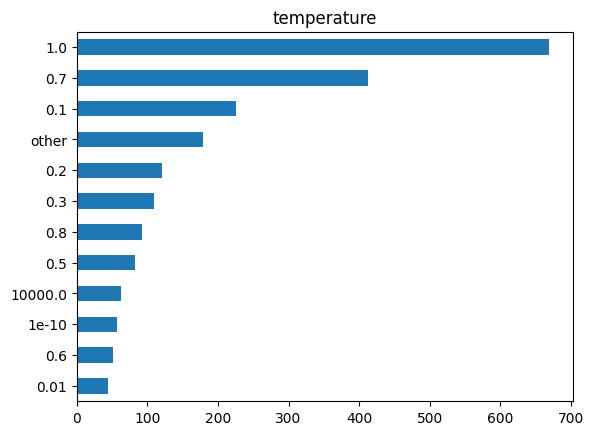

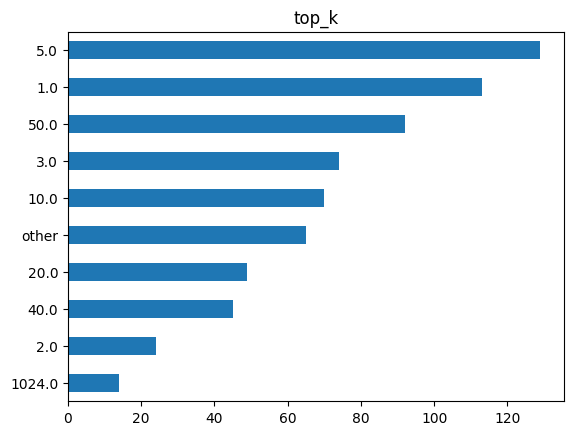

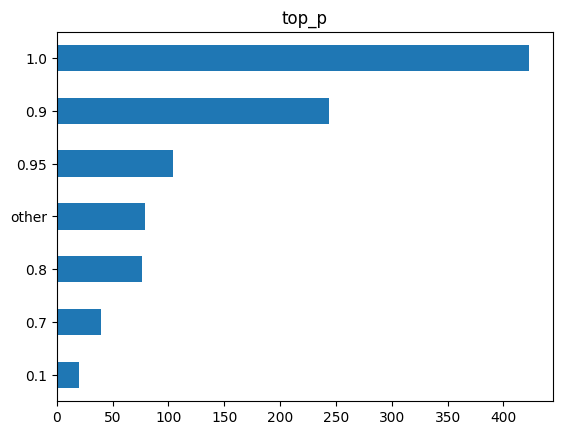

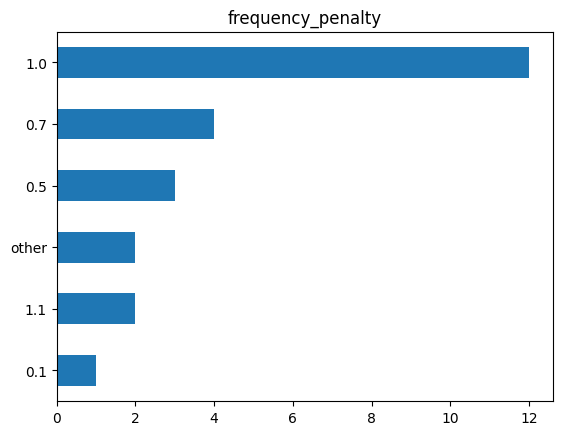

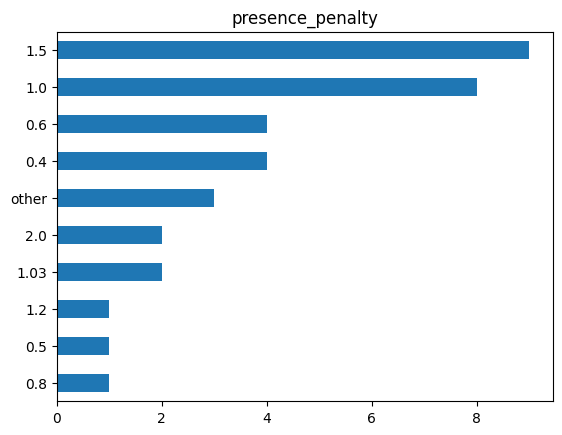

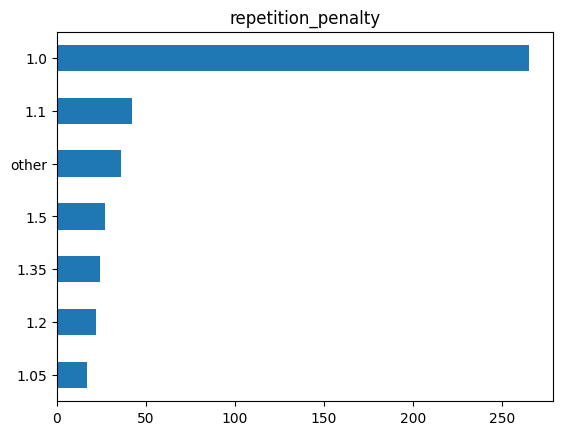

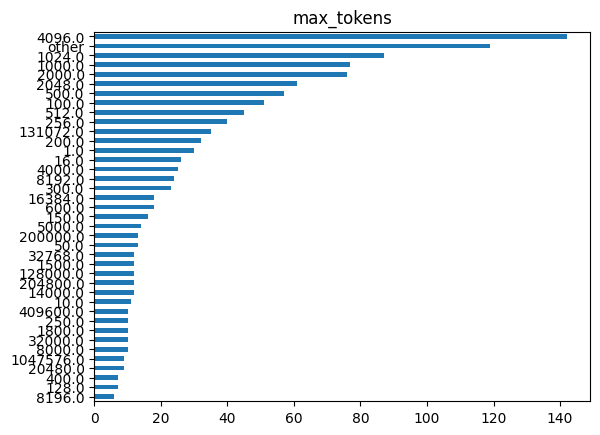

In [27]:
parameters = ['temperature', 'top_k', 'top_p', 'frequency_penalty', 'presence_penalty', 'repetition_penalty', 'max_tokens']
    
df_5 = df.drop(columns=['project_name', 'path', 'lineno'])
df_5['value'] = df_5['value'].dropna()
df_5['value'] = pd.to_numeric(df_5['value'], errors='coerce')

for parameter in parameters:
    print(parameter)
    param_df = df_5.loc[df_5['parameter'] == parameter]
    param_df = param_df['value']

    total_values = param_df.size
    print(total_values)
    values_count = param_df.value_counts()
    values_count = pd.to_numeric(values_count, errors='coerce')
    # values_count = values_count.sort_index()
    values_count = values_count.sort_values(ascending=False)
    values_count = values_count.to_dict()
    current_percentage = 0
    current_values = 0
    limit_percentage=0.9
    new_value_count = {}
    other_count = 0
    for idx, count in values_count.items():
        #print(idx, count)
        if current_percentage < limit_percentage:
            new_value_count[idx] = count
            current_values += count
            current_percentage = current_values / total_values
        else:
            other_count += count
    new_value_count['other'] = other_count
    new_value_count = pd.Series(data=new_value_count, index=new_value_count.keys())
    new_value_count = new_value_count.sort_values()
    print(new_value_count)
    
    plt.figure()
    new_value_count.plot.barh(title=parameter)

## How many models does each project use?

In [28]:
df_6 = df_only_model.drop(columns=['path', 'lineno', 'parameter'])
#t = df_4.groupby(['project_name']).count()

t = df_6.value_counts().groupby(['project_name', 'value']).value_counts()
#t.hist()
d = t.groupby(['project_name']).count()
d.describe()

count    265.000000
mean       4.101887
std        7.065240
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       96.000000
Name: count, dtype: float64

**There are 135 projects that do not have a defined model**